In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\Shahzadi\\Desktop\\fyp folder\\dataset1.csv")
df.head()

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


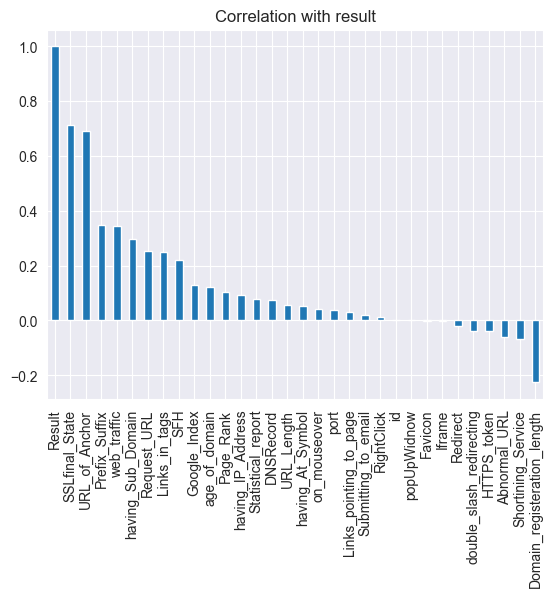

In [3]:
df.head()
corr = df.corr(numeric_only=True)
corr_target = corr['Result'].sort_values(ascending=False)
corr_target.plot(kind='bar')
plt.title("Correlation with result")
plt.show()

In [4]:
df.drop(columns=['id', 'Abnormal_URL', 'HTTPS_token', 'Favicon', 'Iframe','popUpWidnow', 'Page_Rank','RightClick', 'on_mouseover'], inplace=True,errors='ignore')

In [5]:
df['Result'] = df['Result'].map({-1: 0, 1: 1})

X = df.drop('Result', axis=1)
y = df['Result']
print("X shape:", X.shape)
print("Label counts:\n", y.value_counts())

X shape: (11055, 22)
Label counts:
 Result
1    6157
0    4898
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from catboost import CatBoostClassifier
cat=CatBoostClassifier(iterations=100,learning_rate=0.1,depth=6,loss_function='Logloss',eval_metric='Accuracy',random_seed=42,verbose=False)
cat.fit(x_train, y_train)
print("XGBoost trained successfully!")


XGBoost trained successfully!


In [9]:
y_pred = cat.predict(x_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("         MODEL EVALUATION — XGBOOST")
print("="*55)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"  F1 Score  : {f1_score(y_test, y_pred)*100:.2f}%")
print("="*55)
print(classification_report(y_test, y_pred, target_names=['Phishing','Legitimate']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

         MODEL EVALUATION — XGBOOST
  Accuracy  : 96.38%
  Precision : 96.37%
  Recall    : 97.16%
  F1 Score  : 96.76%
              precision    recall  f1-score   support

    Phishing       0.96      0.95      0.96       980
  Legitimate       0.96      0.97      0.97      1231

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211

Confusion Matrix:
[[ 935   45]
 [  35 1196]]


In [11]:
import re
import joblib
from urllib.parse import urlparse
joblib.dump(cat, 'phishing_model.pkl')
print("\nModel saved as phishing_model.pkl")


Model saved as phishing_model.pkl


In [12]:

import requests
import whois
from datetime import datetime
from urllib.parse import urlparse
from bs4 import BeautifulSoup
def extract_features(url):
    parsed = urlparse(url)
    netloc = parsed.netloc
    path   = parsed.path

    # ── Features extracted from URL string alone ──────────
    having_IP_Address = 1 if re.match(
        r'\d+\.\d+\.\d+\.\d+', netloc) else -1

    url_length = 1 if len(url) < 54 else (-1 if len(url) > 75 else 0)

    shortening = -1 if any(s in url for s in [
        'bit.ly','goo.gl','tinyurl','ow.ly','t.co',
        'is.gd','buff.ly','adf.ly']) else 1

    having_At_Symbol = -1 if '@' in url else 1

    double_slash = -1 if '//' in path else 1

    prefix_suffix = -1 if '-' in netloc else 1

    dots = netloc.count('.')
    having_Sub_Domain = -1 if dots > 2 else (0 if dots == 2 else 1)

    SSLfinal_State = 1 if parsed.scheme == 'https' else -1

    port = -1 if ':' in netloc else 1

    submitting_email = -1 if 'mailto:' in url else 1

    statistical_report = -1 if any(s in url for s in [
        'bit.ly','goo.gl']) else 1

    # ── Features from WHOIS — domain age ──────────────────
    try:
        w = whois.whois(netloc)
        creation = w.creation_date
        if isinstance(creation, list):
            creation = creation[0]
        if creation:
            age_days = (datetime.now() - creation).days
            # dataset encoding: 1=old(safe), -1=new(suspicious)
            domain_reg_length = 1 if age_days > 365 else -1
            age_of_domain     = 1 if age_days > 180 else -1
        else:
            domain_reg_length = -1
            age_of_domain     = -1
    except Exception:
        # If WHOIS fails — treat as suspicious (unknown new domain)
        domain_reg_length = -1
        age_of_domain     = -1

    # ── Features from webpage content ─────────────────────
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, timeout=5, headers=headers,
                                allow_redirects=True)
        soup = BeautifulSoup(response.text, 'html.parser')
        page_text = response.text

        # Request_URL — ratio of external images/scripts/links
        total_media = len(soup.find_all(['img','script','link']))
        ext_media   = sum(1 for tag in soup.find_all(['img','script','link'])
                         if tag.get('src','').startswith('http') or
                            tag.get('href','').startswith('http'))
        if total_media == 0:
            Request_URL = 0
        else:
            ratio = ext_media / total_media
            Request_URL = 1 if ratio < 0.22 else (-1 if ratio > 0.61 else 0)

        # URL_of_Anchor — ratio of anchor tags with suspicious hrefs
        anchors = soup.find_all('a', href=True)
        if not anchors:
            URL_of_Anchor = 0
        else:
            suspicious = sum(1 for a in anchors if
                a['href'] in ['#','#skip','#content'] or
                a['href'].startswith('javascript'))
            ratio = suspicious / len(anchors)
            URL_of_Anchor = 1 if ratio < 0.31 else (-1 if ratio > 0.67 else 0)

        # Links_in_tags — ratio of links in meta/script/link tags
        link_tags = soup.find_all(['meta','script','link'])
        if not link_tags:
            Links_in_tags = 0
        else:
            ext_links = sum(1 for t in link_tags
                           if str(t).startswith('http'))
            ratio = ext_links / len(link_tags)
            Links_in_tags = 1 if ratio < 0.17 else (
                            -1 if ratio > 0.81 else 0)

        # SFH — form action URL
        forms = soup.find_all('form')
        if not forms:
            SFH = 1   # no forms = safe
        else:
            actions = [f.get('action','') for f in forms]
            suspicious_sfh = any(
                a == '' or a == 'about:blank' or
                (a.startswith('http') and netloc not in a)
                for a in actions)
            SFH = -1 if suspicious_sfh else 1

        # web_traffic — based on response time as a rough proxy
        resp_time = response.elapsed.total_seconds()
        web_traffic = 1 if resp_time < 1.0 else (
                      0 if resp_time < 3.0 else -1)

        # DNSRecord — if page loaded successfully, DNS resolves
        DNSRecord = 1

        # Google_Index — check if google returns results
        try:
            g = requests.get(
                f'https://www.google.com/search?q=site:{netloc}',
                headers=headers, timeout=5)
            Google_Index = 1 if 'did not match any documents' not in g.text else -1
        except Exception:
            Google_Index = 0

    except Exception:
        # If page cannot be fetched — treat all as suspicious
        Request_URL   = -1
        URL_of_Anchor = -1
        Links_in_tags = -1
        SFH           = -1
        web_traffic   = -1
        DNSRecord     = -1
        Google_Index  = -1

    return {
        'having_IP_Address'           : having_IP_Address,
        'URL_Length'                  : url_length,
        'Shortining_Service'          : shortening,
        'having_At_Symbol'            : having_At_Symbol,
        'double_slash_redirecting'    : double_slash,
        'Prefix_Suffix'               : prefix_suffix,
        'having_Sub_Domain'           : having_Sub_Domain,
        'SSLfinal_State'              : SSLfinal_State,
        'Domain_registeration_length' : domain_reg_length,
        'port'                        : port,
        'Request_URL'                 : Request_URL,
        'URL_of_Anchor'               : URL_of_Anchor,
        'Links_in_tags'               : Links_in_tags,
        'SFH'                         : SFH,
        'Submitting_to_email'         : submitting_email,
        'Redirect'                    : 0,
        'age_of_domain'               : age_of_domain,
        'DNSRecord'                   : DNSRecord,
        'web_traffic'                 : web_traffic,
        'Google_Index'                : Google_Index,
        'Links_pointing_to_page'      : 0,
        'Statistical_report'          : statistical_report,
    }

In [15]:
def predict_url(url):
    print("\nFetching URL data... please wait a moment.")

    features     = extract_features(url)
    feature_cols = x_train.columns.tolist()
    input_data   = pd.DataFrame([features])[feature_cols]
    prediction   = cat.predict(input_data)[0]
    confidence   = cat.predict_proba(input_data).max() * 100

    print("\n" + "="*55)
    print(f"  URL       : {url}")
    print("="*55)
    if confidence < 70:
        print(f"  RESULT    : SUSPICIOUS — Cannot determine safely")
        print(f"  WARNING   : Low confidence ({confidence:.1f}%) — treat with caution")
    elif prediction == 1:
        print(f"  RESULT    : LEGITIMATE WEBSITE")
        print(f"  CONFIDENCE: {confidence:.1f}%")
    else:
        print(f"  RESULT    : PHISHING / UNSAFE WEBSITE")
        print(f"  CONFIDENCE: {confidence:.1f}%")
    print("="*55)

    # Show what features were extracted
    print("\nExtracted features:")
    for k, v in features.items():
        print(f"  {k:<35} = {v}")

In [16]:
user_url = input("\nPaste any URL to check: ")
predict_url(user_url)


Fetching URL data... please wait a moment.

  URL       : https://www.youtube.com/watch?v=ZI1Wqp2n25k&t=2s
  RESULT    : LEGITIMATE WEBSITE
  CONFIDENCE: 99.9%

Extracted features:
  having_IP_Address                   = -1
  URL_Length                          = 1
  Shortining_Service                  = 1
  having_At_Symbol                    = 1
  double_slash_redirecting            = 1
  Prefix_Suffix                       = 1
  having_Sub_Domain                   = 0
  SSLfinal_State                      = 1
  Domain_registeration_length         = -1
  port                                = 1
  Request_URL                         = 0
  URL_of_Anchor                       = 1
  Links_in_tags                       = 1
  SFH                                 = 1
  Submitting_to_email                 = 1
  Redirect                            = 0
  age_of_domain                       = -1
  DNSRecord                           = 1
  web_traffic                         = 1
  Google_Index   